# **PoliMillionaire - *Literally Losing My-mind***

**Project Overview:**

The project focuses on the development of an autonomous chatbot to compete in the 'Who Wants to be a PoliMillionaire?' online quiz. The system leverages locally-hosted models to provide accurate answers within a 30-second timeout, exploring advanced NLP techniques such as RAG and Agentic AI.


**Course Information:**
```
- University: Politecnico di Milano
- Course: Natural Language Processing (NLP)
- Academic Year: 2025/2026
- Professor: Mark Carman James
```

**Team Members:**
```
- Jasmine Spinetto
- Olga Eskarous
- Luca Colangelo
- Hossam Eldin Ahmed Hussien
- Andrea Mikhaiel
```

**GitHub repository:** https://github.com/JasminSpinetto/NLP_challenge





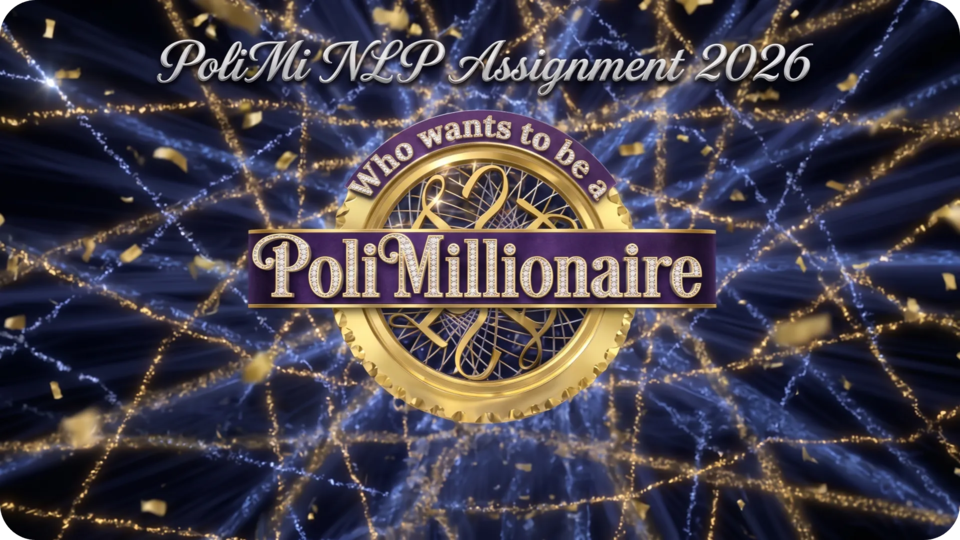

## ⚙️ Libraries Import

In [ ]:
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Import necessary modules
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import userdata

## ⏳ Loading Data & Utils

```
gdrive_home/
├── NLP_assignment/
│     ├── PoliMillionaire.ipynb  <-- Notebook
│     └── millionaire_client/    <-- Utils Directory
```

In [ ]:
from google.colab import drive
import os
drive.mount('/content/gdrive/')

In [ ]:
path = 'NLP_assignement'

os.chdir(f'/content/gdrive/MyDrive/{path}')
os.getcwd()

In [ ]:
from millionaire_client import MillionaireClient, AuthenticationError

## ➜] Login

In [ ]:
API_URL = "http://131.175.15.22:51111/"
username = "Username"
password = userdata.get('poli-millionaire')

In [ ]:
client = MillionaireClient("API_URL")

try:
    user = client.login("USERNAME", "PASSWORD")
    print(f"\nWelcome, {user.username}! (Role: {user.role})")
except AuthenticationError as e:
    print(f"Login failed: {e}")

## 🕹️ Play

In [ ]:
def list_competitions():
  """
  Lists available competitions.
  """

  print("\n=== Available Competitions ===")
  competitions = client.competitions.list_all()
  for comp in competitions:
    print(f"  {comp.id}: {comp.name} ({comp.max_levels} questions)")

In [ ]:
def show_leaderboard(comp_id):
  """
  Shows leaderboard position for the given competition id.
  """

  lb = client.leaderboard.get(competition_id=comp_id, limit=10)
  print(f"\n=== Leaderboard for {lb.competition.name} ===")
  for i, entry in enumerate(lb.entries[:5], 1):
      marker = " <-- YOU" if entry.username == username else ""
      print(f"  {i}. {entry.username}: ${entry.score:,.2f} (Level {entry.reached_level}){marker}")

In [ ]:
def play(model):
  """
  Runs an interactive quiz session against the online platform.
  Allows the user to select a competition, play multiple games, and
  tracks performance history (games played, levels reached, scores).
  At the end of the session, prints a summary with average statistics
  for each competition played.
  """

  # Session summary
  num_competitions = len(client.competitions.list_all())
  play_history = {
      str(i): {"num_games": 0, "level": [], "score": []}
      for i in range(num_competitions)
  }

  while(True):
      # List available competitions
      list_competitions()

      # Choose a competition ID
      comp_id = input("Enter competition ID:")
      play_history[comp_id]["num_games"] += 1

      # Start the game
      print("\n=== Starting Game ===")
      game = client.game.start(competition_id=comp_id)
      print(f"Session ID: {game.session_id}")
      print(f"Total number of questions: {game.state.competition.max_levels}")
      print()

      # Play the game
      while game.in_progress:
          question = game.current_question
          if not question:
              print("No question available. Game may have ended.")
              break

          print(f"\n--- Level {game.current_level} ---")
          print(f"Q: {question.text}")
          print()

          for opt in question.options:
              print(f"  [{opt.id}] {opt.text}")
          options = {
              str(opt.id) : opt.text
              for opt in question.options
          }

          # Get answer
          answer_id = model.answer(question.text, options)
          print(f"\nSelected answer: {answer_id}")

          # Get time remaining
          time_left = game.time_remaining
          if time_left:
              print(f"Time to answer: {30.0 - time_left:.1f}s")

          # Submit answer
          result = game.answer(answer_id)

          if result.correct:
              print("\n CORRECT!")
              if result.game_over:
                  print(f"\n CONGRATULATIONS! You completed the game!")
                  print(f" Final earnings: ${result.earned_amount:,.2f}")
              else:
                  print(f" Earned so far: ${result.earned_amount:,.2f}")
          elif result.timed_out:
              print("\nTIMED OUT!")
              print(f"\n Game Over!")
              print(f" Final earnings: ${result.earned_amount:,.2f}")
          elif not result.correct:
              print("\n WRONG ANSWER!")
              print(f"\n Game Over!")
              print(f" Final earnings: ${result.earned_amount:,.2f}")

      print("\n=== Game Summary ===")
      print(f"Reached Level: {game.current_level}")
      print(f"Total Earnings: ${game.earned_amount:,.2f}")
      print()

      play_history[comp_id]["level"].append(game.current_level - 1)
      play_history[comp_id]["score"].append(game.earned_amount)

      play_again = input("Play again? [Y/N]: ")
      if play_again.lower() == 'n':
          break

  print("\n=== Session Summary ===")
  for comp_id in play_history.keys():
      num_games = play_history[comp_id]["num_games"]
      if num_games == 0: continue

      print(f"\nCOMPETITION {comp_id}:")
      print(f"Number of games: {num_games}")
      print(f"Average correct answers: {sum(play_history[comp_id]["level"])/num_games:,.2f}")
      print(f"Average score: {sum(play_history[comp_id]["score"])/num_games:,.2f}")